<a href="https://colab.research.google.com/github/wldnjs0122/2026-BDA/blob/main/11w.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **빅데이터분석프로그래밍**

# 파이썬 설치 확인

In [ ]:
import site
site.getsitepackages()

['/usr/local/lib/python3.12/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/lib/python3.12/dist-packages']

In [ ]:
import sys
import pandas as pd
import numpy as np
import seaborn as sns

print(sys.version)
print(pd.__version__)
print(np.__version__)
print(sns.__version__)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
2.2.2
2.0.2
0.13.2


# 코랩에서 한글 처리

In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
# 그림 선명하게
%config InlineBackend.figure_format = 'retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 54.1 MB/s eta 0:00:00


In [ ]:
# 데이터프레임의 소수점 이하 n(2)자리 출력 설정
pd.set_option('display.precision', 2)
# pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
# 전체 초기화
# pd.reset_option('all')
# pd.reset_option('display.precision')

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [4, 3]

In [ ]:
from IPython.display import display_html
import inspect
import ast

def display_side_by_side(*dfs):
    titles = []

    try:
        caller_frame = inspect.currentframe().f_back
        call_line = inspect.getframeinfo(caller_frame).code_context[0].strip()

        tree = ast.parse(call_line)
        call = tree.body[0].value

        if isinstance(call, ast.Call):
            for arg in call.args:
                titles.append(ast.get_source_segment(call_line, arg))
    except:
        titles = [''] * len(dfs)

    if len(titles) < len(dfs):
        titles += [''] * (len(dfs) - len(titles))

    html_str = ''
    for df, title in zip(dfs, titles):
        html_str += f"""
        <div style="display:inline-block; vertical-align:top; margin-right:20px; text-align:center;">
            <div style="font-weight:bold; font-size:13px; margin-bottom:8px; text-align:center;">
                {title}
            </div>
            <div style="display:flex; justify-content:center;">
                {df.to_html()}
            </div>
        </div>
        """

    display_html(html_str, raw=True)

In [ ]:
from IPython.display import display_html
import inspect
import ast

def display_series_side_by_side(*args):
    """여러 Series를 옆으로 나란히 표시하고,
    호출 시 사용한 표현식을 제목으로 위에 출력한다.
    """
    titles = []

    try:
        caller_frame = inspect.currentframe().f_back
        call_line = inspect.getframeinfo(caller_frame).code_context[0].strip()

        tree = ast.parse(call_line)
        call = tree.body[0].value

        if isinstance(call, ast.Call):
            for arg in call.args:
                titles.append(ast.get_source_segment(call_line, arg))
    except:
        titles = [''] * len(args)

    if len(titles) < len(args):
        titles += [''] * (len(args) - len(titles))

    html_str = ''
    for s, title in zip(args, titles):
        table_html = s.to_frame().to_html()

        html_str += f"""
        <div style="display:inline-block; vertical-align:top; margin-right:20px; text-align:center;">
            <div style="font-weight:bold; font-size:13px; margin-bottom:8px; text-align:center;">
                {title}
            </div>
            <div style="display:flex; justify-content:center;">
                {table_html}
            </div>
        </div>
        """

    display_html(html_str, raw=True)

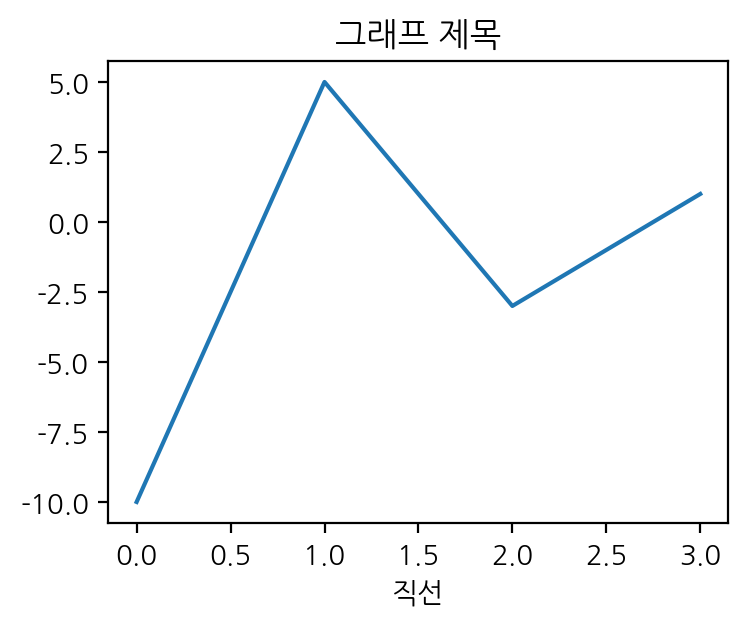

In [ ]:
import matplotlib.pyplot as plt

plt.plot([-10, 5, -3, 1])
plt.title('그래프 제목')
plt.xlabel('직선')
plt.show()

## 수업에서 사용할 데이터를 다음 깃에서 복사
- https://github.com/ai7dnn/data.git

> #### 수업에서 파일 사용 시
> - 현재 하부 폴더: data
> - 파일: data/파일이름

In [ ]:
!git clone https://github.com/ai7dnn/data.git

Cloning into 'data'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 50 (delta 12), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 5.71 MiB | 5.13 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [ ]:
import pandas as pd

exam = pd.read_csv('data/exam.csv')
exam.head()

,id,nclass,math,english,science
0,1,1,50,98,50
1,2,1,60,97,60
2,3,1,45,86,78
3,4,1,30,98,58
4,5,2,25,80,65


In [ ]:
exam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       20 non-null     int64
 1   nclass   20 non-null     int64
 2   math     20 non-null     int64
 3   english  20 non-null     int64
 4   science  20 non-null     int64
dtypes: int64(5)
memory usage: 932.0 bytes


In [ ]:
exam.describe()

,id,nclass,math,english,science
count,20.00,20.00,20.00,20.00,20.00
mean,10.50,3.00,57.45,84.90,59.45
std,5.92,1.45,20.30,12.88,25.29
min,1.00,1.00,20.00,56.00,12.00
25%,5.75,2.00,45.75,78.00,45.00
50%,10.50,3.00,54.00,86.50,62.50
75%,15.25,4.00,75.75,98.00,78.00
max,20.00,5.00,90.00,98.00,98.00


In [ ]:
exam.describe()[['math', 'english', 'science']]

,math,english,science
count,20.00,20.00,20.00
mean,57.45,84.90,59.45
std,20.30,12.88,25.29
min,20.00,56.00,12.00
25%,45.75,78.00,45.00
50%,54.00,86.50,62.50
75%,75.75,98.00,78.00
max,90.00,98.00,98.00


In [ ]:
exam.nclass.unique()

array([1, 2, 3, 4, 5])

In [ ]:
exam.nclass.value_counts()

,count
nclass,
1,4
2,4
3,4
4,4
5,4


In [ ]:
display_side_by_side(exam.head(), exam.tail())

,id,nclass,math,english,science
0,1,1,50,98,50
1,2,1,60,97,60
2,3,1,45,86,78
3,4,1,30,98,58
4,5,2,25,80,65
,id,nclass,math,english,science
15,16,4,58,98,65
16,17,5,65,68,98
17,18,5,80,78,90
18,19,5,89,68,87


## DataFrame.agg('sum')/Series.agg('sum')

In [ ]:
exam.agg("mean")

,0
id,10.50
nclass,3.00
math,57.45
english,84.90
science,59.45


In [ ]:
exam.agg("mean")

,0
id,10.50
nclass,3.00
math,57.45
english,84.90
science,59.45


In [ ]:
exam.agg("median")

,0
id,10.5
nclass,3.0
math,54.0
english,86.5
science,62.5


In [ ]:
exam.agg("nunique")

,0
id,20
nclass,5
math,15
english,13
science,13


In [ ]:
exam.mean()

,0
id,10.50
nclass,3.00
math,57.45
english,84.90
science,59.45


In [ ]:
display_series_side_by_side(exam.mean(), exam.agg("mean"))

,0
id,10.50
nclass,3.00
math,57.45
english,84.90
science,59.45
,0
id,10.50
nclass,3.00
math,57.45
english,84.90


In [ ]:
exam.agg("mean", axis=1)

,0
0,40.0
1,44.0
2,42.6
3,38.2
4,35.4
5,49.0
6,44.8
7,40.6
8,29.0
9,41.2


In [ ]:
exam.mean(axis=1)

,0
0,40.0
1,44.0
2,42.6
3,38.2
4,35.4
5,49.0
6,44.8
7,40.6
8,29.0
9,41.2


In [ ]:
exam.agg(["mean", "max", "min", "median"])

,id,nclass,math,english,science
mean,10.5,3.0,57.45,84.9,59.45
max,20.0,5.0,90.00,98.0,98.00
min,1.0,1.0,20.00,56.0,12.00
median,10.5,3.0,54.00,86.5,62.50


In [ ]:
display_side_by_side(exam.agg("mean").to_frame(), exam.agg(["mean", "max", "min", "median"]))

exam.agg("mean").to_frame()
 
 
 
 
 
 
 0 
 
 
 
 
 id 
 10.50 
 
 
 nclass 
 3.00 
 
 
 math 
 57.45 
 
 
 english 
 84.90 
 
 
 science 
 59.45 
 
 
 
 
 
 
 
 
 exam.agg(["mean", "max", "min", "median"])
 
 
 
 
 
 
 id 
 nclass 
 math 
 english 
 science 
 
 
 
 
 mean 
 10.5 
 3.0 
 57.45 
 84.9 
 59.45 
 
 
 max 
 20.0 
 5.0 
 90.00 
 98.0 
 98.00 
 
 
 min 
 1.0 
 1.0 
 20.00 
 56.0 
 12.00 
 
 
 median 
 10.5 
 3.0 
 54.00 
 86.5 
 62.50

In [ ]:
display_side_by_side(exam.agg(["count", "mean", "std", "min", "median", "max"]), exam.describe())

,id,nclass,math,english,science
count,20.00,20.00,20.00,20.00,20.00
mean,10.50,3.00,57.45,84.90,59.45
std,5.92,1.45,20.30,12.88,25.29
min,1.00,1.00,20.00,56.00,12.00
median,10.50,3.00,54.00,86.50,62.50
max,20.00,5.00,90.00,98.00,98.00
,id,nclass,math,english,science
count,20.00,20.00,20.00,20.00,20.00
mean,10.50,3.00,57.45,84.90,59.45
std,5.92,1.45,20.30,12.88,25.29


In [ ]:
display_series_side_by_side(exam.mean(), exam.agg("mean"))

,0
id,10.50
nclass,3.00
math,57.45
english,84.90
science,59.45
,0
id,10.50
nclass,3.00
math,57.45
english,84.90


In [ ]:
exam.agg(mean_math = ('math', 'mean'))

,math
mean_math,57.45


In [ ]:
exam.agg(수학평균 = ('math', 'mean'))

,math
수학평균,57.45


In [ ]:
exam.agg(수학평균 = ('math', 'mean'), 영어최고 = ('english', 'max'))

,math,english
수학평균,57.45,NaN
영어최고,NaN,98.0


In [ ]:
exam.agg(영어최고 = ('english', 'max'))

,english
영어최고,98


In [ ]:
pd.DataFrame([
    {'지표': '수학평균', '값': exam['math'].mean()},
    {'지표': '영어최고', '값': exam['english'].max()}
]).set_index('지표')

,값
지표,
수학평균,57.45
영어최고,98.00


In [ ]:
pd.DataFrame([
    {'지표': '수학평균', '값': exam['math'].mean()},
    {'지표': '영어최고', '값': exam['english'].max()},
    {'지표': '과학최저', '값': exam['science'].min()}
]).set_index('지표')

,값
지표,
수학평균,57.45
영어최고,98.00
과학최저,12.00


In [ ]:
import numpy as np
df = pd.DataFrame([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9],
                   [np.nan, np.nan, 10]],
                   columns=['A', 'B', 'C'])
df

,A,B,C
0,1.0,2.0,3
1,4.0,5.0,6
2,7.0,8.0,9
3,NaN,NaN,10


In [ ]:
df.agg(['count', 'sum', 'mean', 'min', 'median', 'max'])

,A,B,C
count,3.0,3.0,4.0
sum,12.0,15.0,28.0
mean,4.0,5.0,7.0
min,1.0,2.0,3.0
median,4.0,5.0,7.5
max,7.0,8.0,10.0


In [ ]:
df.agg(['count', 'sum', 'mean', 'min', 'median', 'max'], axis=0)

,A,B,C
count,3.0,3.0,4.0
sum,12.0,15.0,28.0
mean,4.0,5.0,7.0
min,1.0,2.0,3.0
median,4.0,5.0,7.5
max,7.0,8.0,10.0


In [ ]:
exam

,id,nclass,math,english,science
0,1,1,50,98,50
1,2,1,60,97,60
2,3,1,45,86,78
3,4,1,30,98,58
4,5,2,25,80,65
5,6,2,50,89,98
6,7,2,80,90,45
7,8,2,90,78,25
8,9,3,20,98,15
9,10,3,50,98,45


In [ ]:
df.agg(['count', 'sum', 'mean', 'min', 'median', 'max'], axis='index')

,A,B,C
count,3.0,3.0,4.0
sum,12.0,15.0,28.0
mean,4.0,5.0,7.0
min,1.0,2.0,3.0
median,4.0,5.0,7.5
max,7.0,8.0,10.0


In [ ]:
df

,A,B,C
0,1.0,2.0,3
1,4.0,5.0,6
2,7.0,8.0,9
3,NaN,NaN,10


In [ ]:
df.agg(['count', 'sum', 'mean', 'min', 'median', 'max'], axis=1)

,count,sum,mean,min,median,max
0,3.0,6.0,2.0,1.0,2.0,3.0
1,3.0,15.0,5.0,4.0,5.0,6.0
2,3.0,24.0,8.0,7.0,8.0,9.0
3,1.0,10.0,10.0,10.0,10.0,10.0


In [ ]:
df.agg(['count', 'sum', 'mean', 'min', 'median', 'max'], axis='columns')

,count,sum,mean,min,median,max
0,3.0,6.0,2.0,1.0,2.0,3.0
1,3.0,15.0,5.0,4.0,5.0,6.0
2,3.0,24.0,8.0,7.0,8.0,9.0
3,1.0,10.0,10.0,10.0,10.0,10.0


### 집단별 요약 통계량 구하기

In [ ]:
exam

,id,nclass,math,english,science
0,1,1,50,98,50
1,2,1,60,97,60
2,3,1,45,86,78
3,4,1,30,98,58
4,5,2,25,80,65
5,6,2,50,89,98
6,7,2,80,90,45
7,8,2,90,78,25
8,9,3,20,98,15
9,10,3,50,98,45


In [ ]:
exam.groupby('nclass').mean()

,id,math,english,science
nclass,,,,
1,2.5,46.25,94.75,61.50
2,6.5,61.25,84.25,58.25
3,10.5,45.00,86.50,39.25
4,14.5,56.75,84.75,55.00
5,18.5,78.00,74.25,83.25


In [ ]:
exam.groupby('nclass').agg(mean_math = ('math', 'mean'))

,mean_math
nclass,
1,46.25
2,61.25
3,45.00
4,56.75
5,78.00


In [ ]:
display_side_by_side(exam.sample(6), exam.groupby('nclass').mean(), exam.groupby('nclass').agg('mean'))

exam.sample(6)
 
 
 
 
 
 
 id 
 nclass 
 math 
 english 
 science 
 
 
 
 
 19 
 20 
 5 
 78 
 83 
 58 
 
 
 14 
 15 
 4 
 75 
 56 
 78 
 
 
 9 
 10 
 3 
 50 
 98 
 45 
 
 
 1 
 2 
 1 
 60 
 97 
 60 
 
 
 10 
 11 
 3 
 65 
 65 
 65 
 
 
 17 
 18 
 5 
 80 
 78 
 90 
 
 
 
 
 
 
 
 
 exam.groupby('nclass').mean()
 
 
 
 
 
 
 id 
 math 
 english 
 science 
 
 
 nclass 
 
 
 
 
 
 
 
 
 1 
 2.5 
 46.25 
 94.75 
 61.50 
 
 
 2 
 6.5 
 61.25 
 84.25 
 58.25 
 
 
 3 
 10.5 
 45.00 
 86.50 
 39.25 
 
 
 4 
 14.5 
 56.75 
 84.75 
 55.00 
 
 
 5 
 18.5 
 78.00 
 74.25 
 83.25 
 
 
 
 
 
 
 
 
 exam.groupby('nclass').agg('mean')
 
 
 
 
 
 
 id 
 math 
 english 
 science 
 
 
 nclass 
 
 
 
 
 
 
 
 
 1 
 2.5 
 46.25 
 94.75 
 61.50 
 
 
 2 
 6.5 
 61.25 
 84.25 
 58.25 
 
 
 3 
 10.5 
 45.00 
 86.50 
 39.25 
 
 
 4 
 14.5 
 56.75 
 84.75 
 55.00 
 
 
 5 
 18.5 
 78.00 
 74.25 
 83.25

In [ ]:
exam.groupby('nclass').agg({'math': ['mean', 'median']})

math       
         mean median
nclass              
1       46.25   47.5
2       61.25   65.0
3       45.00   47.5
4       56.75   53.0
5       78.00   79.0

### 1교시

In [ ]:
exam.groupby('nclass').agg(max_math = ('math', 'max'))

,max_math
nclass,
1,60
2,90
3,65
4,75
5,89


In [ ]:
exam.groupby('nclass').mean()[["math"]]

,math
nclass,
1,46.25
2,61.25
3,45.00
4,56.75
5,78.00


In [ ]:
exam.groupby('nclass').mean()[["math", "english", "science"]]

,math,english,science
nclass,,,
1,46.25,94.75,61.50
2,61.25,84.25,58.25
3,45.00,86.50,39.25
4,56.75,84.75,55.00
5,78.00,74.25,83.25


In [ ]:
exam.groupby('nclass').min()

,id,math,english,science
nclass,,,,
1,1,30,86,50
2,5,25,78,25
3,9,20,65,15
4,13,46,56,12
5,17,65,68,58


In [ ]:
exam.groupby('nclass').agg("mean")

,id,math,english,science
nclass,,,,
1,2.5,46.25,94.75,61.50
2,6.5,61.25,84.25,58.25
3,10.5,45.00,86.50,39.25
4,14.5,56.75,84.75,55.00
5,18.5,78.00,74.25,83.25


In [ ]:
exam.groupby('nclass').agg(["mean", "median"])

id          math        english        science       
        mean median   mean median    mean median    mean median
nclass                                                         
1        2.5    2.5  46.25   47.5   94.75   97.5   61.50   59.0
2        6.5    6.5  61.25   65.0   84.25   84.5   58.25   55.0
3       10.5   10.5  45.00   47.5   86.50   91.5   39.25   38.5
4       14.5   14.5  56.75   53.0   84.75   92.5   55.00   65.0
5       18.5   18.5  78.00   79.0   74.25   73.0   83.25   88.5

In [ ]:
exam.groupby('nclass').agg(["mean", "median", "max"])

id              math            english            science         \
        mean median max   mean median max    mean median max    mean median   
nclass                                                                        
1        2.5    2.5   4  46.25   47.5  60   94.75   97.5  98   61.50   59.0   
2        6.5    6.5   8  61.25   65.0  90   84.25   84.5  90   58.25   55.0   
3       10.5   10.5  12  45.00   47.5  65   86.50   91.5  98   39.25   38.5   
4       14.5   14.5  16  56.75   53.0  75   84.75   92.5  98   55.00   65.0   
5       18.5   18.5  20  78.00   79.0  89   74.25   73.0  83   83.25   88.5   

            
       max  
nclass      
1       78  
2       98  
3       65  
4       78  
5       98

In [ ]:
edf = exam.groupby('nclass').agg(["mean", "median"])
edf['id']

,mean,median
nclass,,
1,2.5,2.5
2,6.5,6.5
3,10.5,10.5
4,14.5,14.5
5,18.5,18.5


In [ ]:
edf[['math', 'science']]

math        science       
         mean median    mean median
nclass                             
1       46.25   47.5   61.50   59.0
2       61.25   65.0   58.25   55.0
3       45.00   47.5   39.25   38.5
4       56.75   53.0   55.00   65.0
5       78.00   79.0   83.25   88.5

In [ ]:
edf

id          math        english        science       
        mean median   mean median    mean median    mean median
nclass                                                         
1        2.5    2.5  46.25   47.5   94.75   97.5   61.50   59.0
2        6.5    6.5  61.25   65.0   84.25   84.5   58.25   55.0
3       10.5   10.5  45.00   47.5   86.50   91.5   39.25   38.5
4       14.5   14.5  56.75   53.0   84.75   92.5   55.00   65.0
5       18.5   18.5  78.00   79.0   74.25   73.0   83.25   88.5

In [ ]:
edf.columns

MultiIndex([(     'id',   'mean'),
            (     'id', 'median'),
            (   'math',   'mean'),
            (   'math', 'median'),
            ('english',   'mean'),
            ('english', 'median'),
            ('science',   'mean'),
            ('science', 'median')],
           )

In [ ]:
edf[('science', 'mean')]

,science
,mean
nclass,
1,61.50
2,58.25
3,39.25
4,55.00
5,83.25


In [ ]:
edf[[('math', 'median'), ('science', 'mean')]]

,math,science
,median,mean
nclass,,
1,47.5,61.50
2,65.0,58.25
3,47.5,39.25
4,53.0,55.00
5,79.0,83.25


### 함수 agg() 인자 사용 방법
- 열 이름은 키워드인 반면, 값 ('열명', '함수명')은 열에서 값을 계산하는 데 사용되는 함수 이름
    - 새_열이름 = ('열명', '함수명')


In [ ]:
exam.groupby('nclass').agg(meanMath = ('math', 'mean'))

,meanMath
nclass,
1,46.25
2,61.25
3,45.00
4,56.75
5,78.00


In [ ]:
exam.groupby('nclass').agg(meanMath = ('math', 'mean'), meanEng = ('english', 'mean'))

,meanMath,meanEng
nclass,,
1,46.25,94.75
2,61.25,84.25
3,45.00,86.50
4,56.75,84.75
5,78.00,74.25


### 함수 agg() 인자 사용 방법: 사전 형식
- {'열명': '함수명'}

In [ ]:
exam.groupby('nclass').agg({'math': 'mean'})

,math
nclass,
1,46.25
2,61.25
3,45.00
4,56.75
5,78.00


In [ ]:
exam.groupby('nclass').agg({'math': ['mean', 'min', 'max']})

math        
         mean min max
nclass               
1       46.25  30  60
2       61.25  25  90
3       45.00  20  65
4       56.75  46  75
5       78.00  65  89

In [ ]:
edf = exam.groupby('nclass').agg({'math': ['mean', 'min', 'max']})
edf.columns

MultiIndex([('math', 'mean'),
            ('math',  'min'),
            ('math',  'max')],
           )

In [ ]:
exam.groupby('nclass').agg(mean_math = ('math', 'mean'))

,mean_math
nclass,
1,46.25
2,61.25
3,45.00
4,56.75
5,78.00


In [ ]:
exam.groupby('nclass', as_index = False).agg(mean_math = ('math', 'mean'))

,nclass,mean_math
0,1,46.25
1,2,61.25
2,3,45.00
3,4,56.75
4,5,78.00


### DataFrameGroupBy 객체

In [ ]:
exam.groupby('nclass')

In [ ]:
type(exam.groupby('nclass'))

pandas.core.groupby.generic.DataFrameGroupBy

In [ ]:
list(range(10))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [ ]:
exam_gb = exam.groupby('nclass')
exam_gb

In [ ]:
list(exam_gb)

[(1,
     id  nclass  math  english  science
  0   1       1    50       98       50
  1   2       1    60       97       60
  2   3       1    45       86       78
  3   4       1    30       98       58),
 (2,
     id  nclass  math  english  science
  4   5       2    25       80       65
  5   6       2    50       89       98
  6   7       2    80       90       45
  7   8       2    90       78       25),
 (3,
      id  nclass  math  english  science
  8    9       3    20       98       15
  9   10       3    50       98       45
  10  11       3    65       65       65
  11  12       3    45       85       32),
 (4,
      id  nclass  math  english  science
  12  13       4    46       98       65
  13  14       4    48       87       12
  14  15       4    75       56       78
  15  16       4    58       98       65),
 (5,
      id  nclass  math  english  science
  16  17       5    65       68       98
  17  18       5    80       78       90
  18  19       5    89       68   

In [ ]:
exam_gb.groups

{1: [0, 1, 2, 3], 2: [4, 5, 6, 7], 3: [8, 9, 10, 11], 4: [12, 13, 14, 15], 5: [16, 17, 18, 19]}

In [ ]:
for key, value in exam_gb:
    print(f'key: {key}')
    print(f'type(value): {type(value)}')
    print(f'value:\n {value}')
    print('='*40, '\n')

key: 1
type(value): <class 'pandas.core.frame.DataFrame'>
value:
    id  nclass  math  english  science
0   1       1    50       98       50
1   2       1    60       97       60
2   3       1    45       86       78
3   4       1    30       98       58

key: 2
type(value): <class 'pandas.core.frame.DataFrame'>
value:
    id  nclass  math  english  science
4   5       2    25       80       65
5   6       2    50       89       98
6   7       2    80       90       45
7   8       2    90       78       25

key: 3
type(value): <class 'pandas.core.frame.DataFrame'>
value:
     id  nclass  math  english  science
8    9       3    20       98       15
9   10       3    50       98       45
10  11       3    65       65       65
11  12       3    45       85       32

key: 4
type(value): <class 'pandas.core.frame.DataFrame'>
value:
     id  nclass  math  english  science
12  13       4    46       98       65
13  14       4    48       87       12
14  15       4    75       56       78
15

In [ ]:
exam.groupby('nclass').agg(mean_math   = ('math', 'mean'),
                           sum_math    = ('math', 'sum'),
                           median_math = ('math', 'median'),
                           count       = ('nclass', 'count'))

,mean_math,sum_math,median_math,count
nclass,,,,
1,46.25,185,47.5,4
2,61.25,245,65.0,4
3,45.00,180,47.5,4
4,56.75,227,53.0,4
5,78.00,312,79.0,4


In [ ]:
exam.groupby('nclass').agg(수학평균   = ('math', 'mean'),
                           수학총합    = ('math', 'sum'),
                           수학중간값 = ('math', 'median'),
                           반_학생수       = ('nclass', 'count'))

,수학평균,수학총합,수학중간값,반_학생수
nclass,,,,
1,46.25,185,47.5,4
2,61.25,245,65.0,4
3,45.00,180,47.5,4
4,56.75,227,53.0,4
5,78.00,312,79.0,4


In [ ]:
exam.groupby('nclass').mean()

,id,math,english,science
nclass,,,,
1,2.5,46.25,94.75,61.50
2,6.5,61.25,84.25,58.25
3,10.5,45.00,86.50,39.25
4,14.5,56.75,84.75,55.00
5,18.5,78.00,74.25,83.25


In [ ]:
exam.groupby('nclass').agg(['mean', 'median'])

id          math        english        science       
        mean median   mean median    mean median    mean median
nclass                                                         
1        2.5    2.5  46.25   47.5   94.75   97.5   61.50   59.0
2        6.5    6.5  61.25   65.0   84.25   84.5   58.25   55.0
3       10.5   10.5  45.00   47.5   86.50   91.5   39.25   38.5
4       14.5   14.5  56.75   53.0   84.75   92.5   55.00   65.0
5       18.5   18.5  78.00   79.0   74.25   73.0   83.25   88.5

In [ ]:
import pandas as pd

mpg = pd.read_csv('data/mpg.csv')
mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   manufacturer  234 non-null    object 
 1   model         234 non-null    object 
 2   displ         234 non-null    float64
 3   year          234 non-null    int64  
 4   cyl           234 non-null    int64  
 5   trans         234 non-null    object 
 6   drv           234 non-null    object 
 7   cty           234 non-null    int64  
 8   hwy           234 non-null    int64  
 9   fl            234 non-null    object 
 10  category      234 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 20.2+ KB


In [ ]:
! pip install pydataset
from pydataset import data

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 52.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=8cbacb282c3d51226e4fee55c1c7fd65636bb981fa62513b1702333e0ddf300b
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset
initiated datasets repo at: /root/.pydataset/


In [ ]:
mpg2 = data('mpg')
mpg2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 234 entries, 1 to 234
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   manufacturer  234 non-null    object 
 1   model         234 non-null    object 
 2   displ         234 non-null    float64
 3   year          234 non-null    int64  
 4   cyl           234 non-null    int64  
 5   trans         234 non-null    object 
 6   drv           234 non-null    object 
 7   cty           234 non-null    int64  
 8   hwy           234 non-null    int64  
 9   fl            234 non-null    object 
 10  class         234 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 21.9+ KB


In [ ]:
mpg.columns

Index(['manufacturer', 'model', 'displ', 'year', 'cyl', 'trans', 'drv', 'cty',
       'hwy', 'fl', 'category'],
      dtype='object')

In [ ]:
mpg.category.unique()

array(['compact', 'midsize', 'suv', '2seater', 'minivan', 'pickup',
       'subcompact'], dtype=object)

In [ ]:
mpg2['class'].unique()

array(['compact', 'midsize', 'suv', '2seater', 'minivan', 'pickup',
       'subcompact'], dtype=object)

In [ ]:
mpg.sample(frac=.02)

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category
208,volkswagen,gti,2.0,1999,4,auto(l4),f,19,26,r,compact
56,dodge,dakota pickup 4wd,5.2,1999,8,auto(l4),4,11,15,r,pickup
112,hyundai,sonata,2.5,1999,6,auto(l4),f,18,26,r,midsize
58,dodge,durango 4wd,4.7,2008,8,auto(l5),4,13,17,r,suv
85,ford,f150 pickup 4wd,4.6,1999,8,manual(m5),4,13,16,r,pickup


In [ ]:
mpg.groupby(['manufacturer', 'drv']).agg(mean_cty = ('cty', 'mean')) # 시험 예상

mean_cty
manufacturer drv          
audi         4       16.82
             f       18.86
chevrolet    4       12.50
             f       18.80
             r       14.10
dodge        4       12.00
             f       15.82
ford         4       13.31
             r       14.75
honda        f       24.44
hyundai      f       18.64
jeep         4       13.50
land rover   4       11.50
lincoln      r       11.33
mercury      4       13.25
nissan       4       13.75
             f       20.00
pontiac      f       17.00
subaru       4       19.29
toyota       4       14.93
             f       21.37
volkswagen   f       20.93

In [ ]:
mpg.groupby(['drv', 'manufacturer']).agg(mean_cty = ('cty', 'mean')) # 시험 예상

mean_cty
drv manufacturer          
4   audi             16.82
    chevrolet        12.50
    dodge            12.00
    ford             13.31
    jeep             13.50
    land rover       11.50
    mercury          13.25
    nissan           13.75
    subaru           19.29
    toyota           14.93
f   audi             18.86
    chevrolet        18.80
    dodge            15.82
    honda            24.44
    hyundai          18.64
    nissan           20.00
    pontiac          17.00
    toyota           21.37
    volkswagen       20.93
r   chevrolet        14.10
    ford             14.75
    lincoln          11.33

In [ ]:
mdf = mpg.groupby(['drv', 'manufacturer']).agg(mean_cty = ('cty', 'mean'))
mdf.sort_values('mean_cty', ascending = False)

mean_cty
drv manufacturer          
f   honda            24.44
    toyota           21.37
    volkswagen       20.93
    nissan           20.00
4   subaru           19.29
f   audi             18.86
    chevrolet        18.80
    hyundai          18.64
    pontiac          17.00
4   audi             16.82
f   dodge            15.82
4   toyota           14.93
r   ford             14.75
    chevrolet        14.10
4   nissan           13.75
    jeep             13.50
    ford             13.31
    mercury          13.25
    chevrolet        12.50
    dodge            12.00
    land rover       11.50
r   lincoln          11.33

In [ ]:
mdf.sort_values(['drv', 'mean_cty'], ascending=[True, False])

mean_cty
drv manufacturer          
4   subaru           19.29
    audi             16.82
    toyota           14.93
    nissan           13.75
    jeep             13.50
    ford             13.31
    mercury          13.25
    chevrolet        12.50
    dodge            12.00
    land rover       11.50
f   honda            24.44
    toyota           21.37
    volkswagen       20.93
    nissan           20.00
    audi             18.86
    chevrolet        18.80
    hyundai          18.64
    pontiac          17.00
    dodge            15.82
r   ford             14.75
    chevrolet        14.10
    lincoln          11.33

In [ ]:
mdf.index

MultiIndex([('4',       'audi'),
            ('4',  'chevrolet'),
            ('4',      'dodge'),
            ('4',       'ford'),
            ('4',       'jeep'),
            ('4', 'land rover'),
            ('4',    'mercury'),
            ('4',     'nissan'),
            ('4',     'subaru'),
            ('4',     'toyota'),
            ('f',       'audi'),
            ('f',  'chevrolet'),
            ('f',      'dodge'),
            ('f',      'honda'),
            ('f',    'hyundai'),
            ('f',     'nissan'),
            ('f',    'pontiac'),
            ('f',     'toyota'),
            ('f', 'volkswagen'),
            ('r',  'chevrolet'),
            ('r',       'ford'),
            ('r',    'lincoln')],
           names=['drv', 'manufacturer'])

In [ ]:
mdf.sort_values(['drv', 'mean_cty'], ascending=[False, True])

mean_cty
drv manufacturer          
r   lincoln          11.33
    chevrolet        14.10
    ford             14.75
f   dodge            15.82
    pontiac          17.00
    hyundai          18.64
    chevrolet        18.80
    audi             18.86
    nissan           20.00
    volkswagen       20.93
    toyota           21.37
    honda            24.44
4   land rover       11.50
    dodge            12.00
    chevrolet        12.50
    mercury          13.25
    ford             13.31
    jeep             13.50
    nissan           13.75
    toyota           14.93
    audi             16.82
    subaru           19.29

In [ ]:
mpg.groupby(['manufacturer', 'category']).agg(mean_cty = ('cty', 'mean'), mean_hwy = ('hwy', 'mean'))

mean_cty  mean_hwy
manufacturer category                      
audi         compact        17.93     26.93
             midsize        16.00     24.00
chevrolet    2seater        15.40     24.80
             midsize        18.80     27.60
             suv            12.67     17.11
dodge        minivan        15.82     22.36
             pickup         12.05     16.11
             suv            11.86     16.00
ford         pickup         13.00     16.43
             subcompact     15.89     23.22
             suv            12.89     17.78
honda        subcompact     24.44     32.56
hyundai      midsize        19.00     27.71
             subcompact     18.29     26.00
jeep         suv            13.50     17.62
land rover   suv            11.50     16.50
lincoln      suv            11.33     17.00
mercury      suv            13.25     18.00
nissan       compact        20.00     28.00
             midsize        20.00     27.43
             suv            13.75     18.00
pontiac      midsize        17.00     26.40
subaru       compact        19.75     26.00
             subcompact     19.50     26.00
             suv            18.83     25.00
toyota       compact        22.25     30.58
             midsize        19.86     28.29
             pickup         15.57     19.43
             suv            14.38     18.25
volkswagen   compact        20.79     28.50
             midsize        18.57     27.57
             subcompact     24.00     32.83

In [ ]:
mpg.query('manufacturer == "audi"').groupby(['drv']).agg(n = ('drv', 'count'))

,n
drv,
4,11
f,7


In [ ]:
mpg[ (mpg.manufacturer == "audi") & (mpg.drv.isin(['4', 'r', 'f'])) ]

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
5,audi,a4,2.8,1999,6,manual(m5),f,18,26,p,compact
6,audi,a4,3.1,2008,6,auto(av),f,18,27,p,compact
7,audi,a4 quattro,1.8,1999,4,manual(m5),4,18,26,p,compact
8,audi,a4 quattro,1.8,1999,4,auto(l5),4,16,25,p,compact
9,audi,a4 quattro,2.0,2008,4,manual(m6),4,20,28,p,compact


In [ ]:
mpg.query("manufacturer == 'audi' and drv in ['4', 'r', 'f']")

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
5,audi,a4,2.8,1999,6,manual(m5),f,18,26,p,compact
6,audi,a4,3.1,2008,6,auto(av),f,18,27,p,compact
7,audi,a4 quattro,1.8,1999,4,manual(m5),4,18,26,p,compact
8,audi,a4 quattro,1.8,1999,4,auto(l5),4,16,25,p,compact
9,audi,a4 quattro,2.0,2008,4,manual(m6),4,20,28,p,compact


In [ ]:
mpg.query('manufacturer == "chevrolet"') \
   .groupby(['drv']).agg(n = ('drv', 'count'))

,n
drv,
4,4
f,5
r,10


In [ ]:
mpg.query('manufacturer == "chevrolet"').groupby(['drv']).count()

,manufacturer,model,displ,year,cyl,trans,cty,hwy,fl,category
drv,,,,,,,,,,
4,4,4,4,4,4,4,4,4,4,4
f,5,5,5,5,5,5,5,5,5,5
r,10,10,10,10,10,10,10,10,10,10


In [ ]:
mpg.query('manufacturer == "chevrolet"').groupby(['drv']).count()[['model']]

,model
drv,
4,4
f,5
r,10


In [ ]:
mpg.query('manufacturer == "chevrolet"').groupby(['drv']).count()[['model']].rename(columns = {'model' : 'n'})

,n
drv,
4,4
f,5
r,10


In [ ]:
mpg.groupby('drv').agg(n = ('drv', 'count'))

,n
drv,
4,103
f,106
r,25


In [ ]:
mpg.groupby('drv').value_counts()

drv  manufacturer  model                displ  year  cyl  trans       cty  hwy  fl  category  
4    dodge         dakota pickup 4wd    4.7    2008  8    auto(l5)    14   19   r   pickup        2
                   durango 4wd          4.7    2008  8    auto(l5)    13   17   r   suv           2
                   ram 1500 pickup 4wd  4.7    2008  8    auto(l5)    13   17   r   pickup        2
                                                          manual(m6)  12   16   r   pickup        2
     ford          explorer 4wd         4.0    1999  6    auto(l5)    14   17   r   suv           2
                                                                                                 ..
r    ford          mustang              4.6    2008  8    manual(m5)  15   23   r   subcompact    1
                                        5.4    2008  8    manual(m6)  14   20   p   subcompact    1
     lincoln       navigator 2wd        5.4    1999  8    auto(l4)    11   16   p   suv           1
                                                                           17   r   suv           1
                                               2008  8    auto(l6)    12   18   r   suv           1
Name: count, Length: 225, dtype: int64

In [ ]:
mpg[['drv', 'cyl']].value_counts()

drv  cyl
f    4      58
4    8      48
f    6      43
4    6      32
     4      23
r    8      21
f    5       4
r    6       4
f    8       1
Name: count, dtype: int64

In [ ]:
mpg[['drv', 'cyl']].value_counts().to_frame()

count
drv cyl       
f   4       58
4   8       48
f   6       43
4   6       32
    4       23
r   8       21
f   5        4
r   6        4
f   8        1

In [ ]:
mpg['drv'].value_counts().to_frame().query('count > 100')

,count
drv,
f,106
4,103


In [ ]:
mpg['drv'].value_counts() \
          .to_frame('n')

,n
drv,
f,106
4,103
r,25


In [ ]:
mpg['drv'].value_counts() \
          .to_frame('n') \
          .query('n > 100')

,n
drv,
f,106
4,103


In [ ]:
mpg['drv'].value_counts().to_frame('n')

,n
drv,
f,106
4,103
r,25


In [ ]:
mpg.groupby('drv').agg(n = ('drv', 'count'))

,n
drv,
4,103
f,106
r,25


In [ ]:
mpg.groupby('drv').agg(n = ('drv', 'count')).query('n > 100')

,n
drv,
4,103
f,106


In [ ]:
mpg.query('category == "suv"') \
   .assign(total = (mpg['hwy'] + mpg['cty']) / 2) \
   .groupby('manufacturer') \
   .agg(mean_tot = ('total', 'mean')) \
   .sort_values('mean_tot', ascending = False) \
   .head(5)

,mean_tot
manufacturer,
subaru,21.92
toyota,16.31
nissan,15.88
mercury,15.62
jeep,15.56


In [ ]:
mpg.query('category == "suv"') \
   .assign(total = (mpg['hwy'] + mpg['cty']) / 2) \
   .groupby('manufacturer') \
   .agg(mean_tot = ('total', 'mean')) \
   .sort_values('mean_tot', ascending = False)

,mean_tot
manufacturer,
subaru,21.92
toyota,16.31
nissan,15.88
mercury,15.62
jeep,15.56
ford,15.33
chevrolet,14.89
lincoln,14.17
land rover,14.00


In [ ]:
name = pd.DataFrame({'nclass'  : [1, 2, 3, 4, 5],
                     'teacher' : ['kim', 'lee', 'park', 'choi', 'jung']})
name

,nclass,teacher
0,1,kim
1,2,lee
2,3,park
3,4,choi
4,5,jung


In [ ]:
exam.sample(5)

,id,nclass,math,english,science
3,4,1,30,98,58
14,15,4,75,56,78
9,10,3,50,98,45
7,8,2,90,78,25
16,17,5,65,68,98


In [ ]:
display_side_by_side(exam.sample(5), name)

exam.sample(5)
 
 
 
 
 
 
 id 
 nclass 
 math 
 english 
 science 
 
 
 
 
 8 
 9 
 3 
 20 
 98 
 15 
 
 
 13 
 14 
 4 
 48 
 87 
 12 
 
 
 16 
 17 
 5 
 65 
 68 
 98 
 
 
 12 
 13 
 4 
 46 
 98 
 65 
 
 
 5 
 6 
 2 
 50 
 89 
 98 
 
 
 
 
 
 
 
 
 name
 
 
 
 
 
 
 nclass 
 teacher 
 
 
 
 
 0 
 1 
 kim 
 
 
 1 
 2 
 lee 
 
 
 2 
 3 
 park 
 
 
 3 
 4 
 choi 
 
 
 4 
 5 
 jung

In [ ]:
pd.merge(exam, name, on ='nclass', how = 'inner')

,id,nclass,math,english,science,teacher
0,1,1,50,98,50,kim
1,2,1,60,97,60,kim
2,3,1,45,86,78,kim
3,4,1,30,98,58,kim
4,5,2,25,80,65,lee
5,6,2,50,89,98,lee
6,7,2,80,90,45,lee
7,8,2,90,78,25,lee
8,9,3,20,98,15,park
9,10,3,50,98,45,park


In [ ]:
group_a = pd.DataFrame({'id'   : [1, 2, 3, 4, 5],
                        'test' : [60, 80, 70, 90, 85]})

group_b = pd.DataFrame({'id'   : [6, 7, 8, 9, 10],
                        'test' : [70, 83, 65, 95, 80]})

In [ ]:
display_side_by_side(group_a, group_b)

,id,test
0,1,60
1,2,80
2,3,70
3,4,90
4,5,85
,id,test
0,6,70
1,7,83
2,8,65
3,9,95


In [ ]:
pd.concat([group_a, group_b])

,id,test
0,1,60
1,2,80
2,3,70
3,4,90
4,5,85
0,6,70
1,7,83
2,8,65
3,9,95
4,10,80


In [ ]:
pd.concat([group_a, group_b]).reset_index()

,index,id,test
0,0,1,60
1,1,2,80
2,2,3,70
3,3,4,90
4,4,5,85
5,0,6,70
6,1,7,83
7,2,8,65
8,3,9,95
9,4,10,80


In [ ]:
pd.concat([group_a, group_b]).reset_index(drop = True)

,id,test
0,1,60
1,2,80
2,3,70
3,4,90
4,5,85
5,6,70
6,7,83
7,8,65
8,9,95
9,10,80


In [ ]:
import pandas as pd

df1 = pd.DataFrame([[1, 'apple'], [2, 'banana']], columns = ['id', 'fruits'])
df1

,id,fruits
0,1,apple
1,2,banana


In [ ]:
df2 = pd.DataFrame([[1, 3000], [5, 500]], columns = ['id', 'price'])
df2

,id,price
0,1,3000
1,5,500


In [ ]:
display_side_by_side(df1, df2)

,id,fruits
0,1,apple
1,2,banana
,id,price
0,1,3000
1,5,500


In [ ]:
pd.merge(df1, df2)

,id,fruits,price
0,1,apple,3000


In [ ]:
pd.merge(df1, df2, how = 'inner')

,id,fruits,price
0,1,apple,3000


In [ ]:
display_side_by_side(df1, df2)

,id,fruits
0,1,apple
1,2,banana
,id,price
0,1,3000
1,5,500


In [ ]:
df1.merge(df2)

,id,fruits,price
0,1,apple,3000


In [ ]:
display_side_by_side(df1, df2, df1.merge(df2))

df1
 
 
 
 
 
 
 id 
 fruits 
 
 
 
 
 0 
 1 
 apple 
 
 
 1 
 2 
 banana 
 
 
 
 
 
 
 
 
 df2
 
 
 
 
 
 
 id 
 price 
 
 
 
 
 0 
 1 
 3000 
 
 
 1 
 5 
 500 
 
 
 
 
 
 
 
 
 df1.merge(df2)
 
 
 
 
 
 
 id 
 fruits 
 price 
 
 
 
 
 0 
 1 
 apple 
 3000

In [ ]:
df1.merge(df2, how='left')

,id,fruits,price
0,1,apple,3000.0
1,2,banana,NaN


In [ ]:
display_side_by_side(df1, df2, df1.merge(df2, how='right'))

df1
 
 
 
 
 
 
 id 
 fruits 
 
 
 
 
 0 
 1 
 apple 
 
 
 1 
 2 
 banana 
 
 
 
 
 
 
 
 
 df2
 
 
 
 
 
 
 id 
 price 
 
 
 
 
 0 
 1 
 3000 
 
 
 1 
 5 
 500 
 
 
 
 
 
 
 
 
 df1.merge(df2, how='right')
 
 
 
 
 
 
 id 
 fruits 
 price 
 
 
 
 
 0 
 1 
 apple 
 3000 
 
 
 1 
 5 
 NaN 
 500

In [ ]:
display_side_by_side(df1, df2, df1.merge(df2, how='outer'))

df1
 
 
 
 
 
 
 id 
 fruits 
 
 
 
 
 0 
 1 
 apple 
 
 
 1 
 2 
 banana 
 
 
 
 
 
 
 
 
 df2
 
 
 
 
 
 
 id 
 price 
 
 
 
 
 0 
 1 
 3000 
 
 
 1 
 5 
 500 
 
 
 
 
 
 
 
 
 df1.merge(df2, how='outer')
 
 
 
 
 
 
 id 
 fruits 
 price 
 
 
 
 
 0 
 1 
 apple 
 3000.0 
 
 
 1 
 2 
 banana 
 NaN 
 
 
 2 
 5 
 NaN 
 500.0

In [ ]:
df1.merge(df2, how='cross')

,id_x,fruits,id_y,price
0,1,apple,1,3000
1,1,apple,5,500
2,2,banana,1,3000
3,2,banana,5,500


In [ ]:
display_side_by_side(df1, df2, df1.merge(df2, how='cross'))

df1
 
 
 
 
 
 
 id 
 fruits 
 
 
 
 
 0 
 1 
 apple 
 
 
 1 
 2 
 banana 
 
 
 
 
 
 
 
 
 df2
 
 
 
 
 
 
 id 
 price 
 
 
 
 
 0 
 1 
 3000 
 
 
 1 
 5 
 500 
 
 
 
 
 
 
 
 
 df1.merge(df2, how='cross')
 
 
 
 
 
 
 id_x 
 fruits 
 id_y 
 price 
 
 
 
 
 0 
 1 
 apple 
 1 
 3000 
 
 
 1 
 1 
 apple 
 5 
 500 
 
 
 2 
 2 
 banana 
 1 
 3000 
 
 
 3 
 2 
 banana 
 5 
 500

In [ ]:
df1 = pd.DataFrame([[1, 'a1'], [2, 'a2']], columns = ['ID', 'X1'])
df2 = pd.DataFrame([[2, 'b1'], [3, 'b2']], columns = ['ID', 'X2'])

In [ ]:
display_side_by_side(df1, df2, df1.merge(df2))

df1
 
 
 
 
 
 
 ID 
 X1 
 
 
 
 
 0 
 1 
 a1 
 
 
 1 
 2 
 a2 
 
 
 
 
 
 
 
 
 df2
 
 
 
 
 
 
 ID 
 X2 
 
 
 
 
 0 
 2 
 b1 
 
 
 1 
 3 
 b2 
 
 
 
 
 
 
 
 
 df1.merge(df2)
 
 
 
 
 
 
 ID 
 X1 
 X2 
 
 
 
 
 0 
 2 
 a2 
 b1

In [ ]:
display_side_by_side(df1, df2, df1.merge(df2, how='inner'))

df1
 
 
 
 
 
 
 ID 
 X1 
 
 
 
 
 0 
 1 
 a1 
 
 
 1 
 2 
 a2 
 
 
 
 
 
 
 
 
 df2
 
 
 
 
 
 
 ID 
 X2 
 
 
 
 
 0 
 2 
 b1 
 
 
 1 
 3 
 b2 
 
 
 
 
 
 
 
 
 df1.merge(df2, how='inner')
 
 
 
 
 
 
 ID 
 X1 
 X2 
 
 
 
 
 0 
 2 
 a2 
 b1

In [ ]:
display_side_by_side(df1, df2, df1.merge(df2, how='outer'))

df1
 
 
 
 
 
 
 ID 
 X1 
 
 
 
 
 0 
 1 
 a1 
 
 
 1 
 2 
 a2 
 
 
 
 
 
 
 
 
 df2
 
 
 
 
 
 
 ID 
 X2 
 
 
 
 
 0 
 2 
 b1 
 
 
 1 
 3 
 b2 
 
 
 
 
 
 
 
 
 df1.merge(df2, how='outer')
 
 
 
 
 
 
 ID 
 X1 
 X2 
 
 
 
 
 0 
 1 
 a1 
 NaN 
 
 
 1 
 2 
 a2 
 b1 
 
 
 2 
 3 
 NaN 
 b2

In [ ]:
display_side_by_side(df1, df2, df1.merge(df2, how='left'))

df1
 
 
 
 
 
 
 ID 
 X1 
 
 
 
 
 0 
 1 
 a1 
 
 
 1 
 2 
 a2 
 
 
 
 
 
 
 
 
 df2
 
 
 
 
 
 
 ID 
 X2 
 
 
 
 
 0 
 2 
 b1 
 
 
 1 
 3 
 b2 
 
 
 
 
 
 
 
 
 df1.merge(df2, how='left')
 
 
 
 
 
 
 ID 
 X1 
 X2 
 
 
 
 
 0 
 1 
 a1 
 NaN 
 
 
 1 
 2 
 a2 
 b1

In [ ]:
display_side_by_side(df1, df2, df1.merge(df2, how='right'))

df1
 
 
 
 
 
 
 ID 
 X1 
 
 
 
 
 0 
 1 
 a1 
 
 
 1 
 2 
 a2 
 
 
 
 
 
 
 
 
 df2
 
 
 
 
 
 
 ID 
 X2 
 
 
 
 
 0 
 2 
 b1 
 
 
 1 
 3 
 b2 
 
 
 
 
 
 
 
 
 df1.merge(df2, how='right')
 
 
 
 
 
 
 ID 
 X1 
 X2 
 
 
 
 
 0 
 2 
 a2 
 b1 
 
 
 1 
 3 
 NaN 
 b2

In [ ]:
display_side_by_side(df1, df2, df1.merge(df2, how='cross'))

df1
 
 
 
 
 
 
 ID 
 X1 
 
 
 
 
 0 
 1 
 a1 
 
 
 1 
 2 
 a2 
 
 
 
 
 
 
 
 
 df2
 
 
 
 
 
 
 ID 
 X2 
 
 
 
 
 0 
 2 
 b1 
 
 
 1 
 3 
 b2 
 
 
 
 
 
 
 
 
 df1.merge(df2, how='cross')
 
 
 
 
 
 
 ID_x 
 X1 
 ID_y 
 X2 
 
 
 
 
 0 
 1 
 a1 
 2 
 b1 
 
 
 1 
 1 
 a1 
 3 
 b2 
 
 
 2 
 2 
 a2 
 2 
 b1 
 
 
 3 
 2 
 a2 
 3 
 b2